In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [7]:
df = pd.read_csv("E:\CLV_Project\online_retail_10_11.csv")

df.head()

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\hp\AppData\Local\Temp\ipykernel_5812\1999927294.py:1: SyntaxWarning: invalid escape sequence '\C'
  df = pd.read_csv("E:\CLV_Project\online_retail_10_11.csv")


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [8]:
df.shape

(541910, 8)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   UnitPrice    541910 non-null  float64
 6   CustomerID   406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [10]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541910.000000,541910.000000,406830.000000
mean,9.552234,4.611138,15287.684160
std,218.080957,96.759765,1713.603074
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [11]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(5268)

In [13]:
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

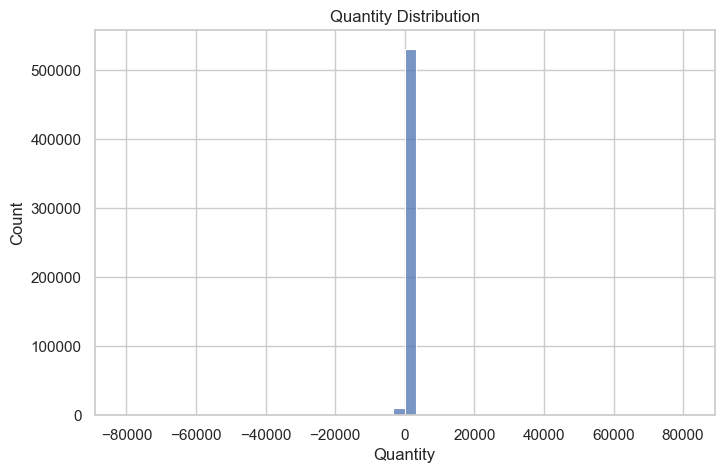

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['Quantity'], bins=50)
plt.title("Quantity Distribution")
plt.show()

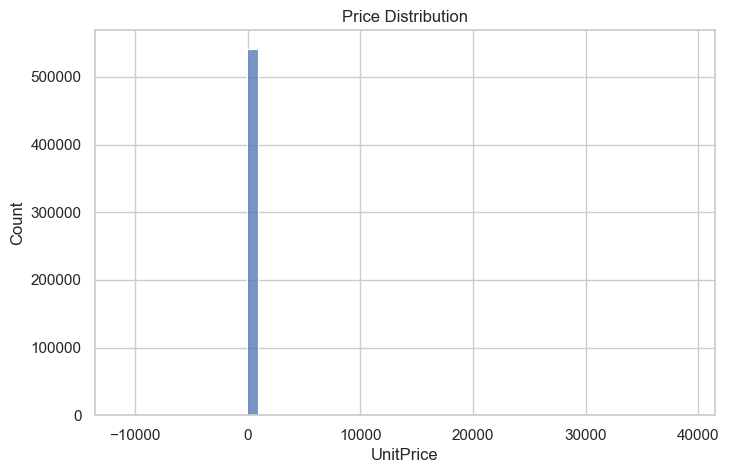

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['UnitPrice'], bins=50)
plt.title("Price Distribution")
plt.show()

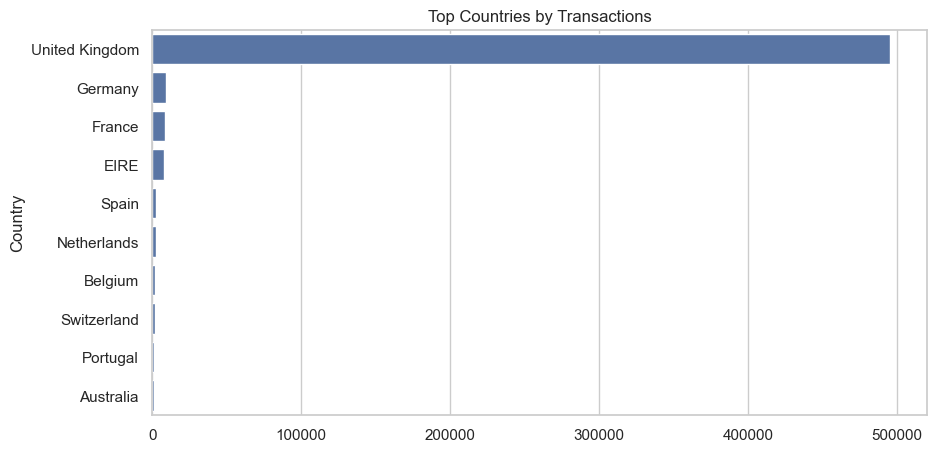

In [18]:
top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top Countries by Transactions")
plt.show()

In [20]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

df[['Quantity', 'UnitPrice', 'Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


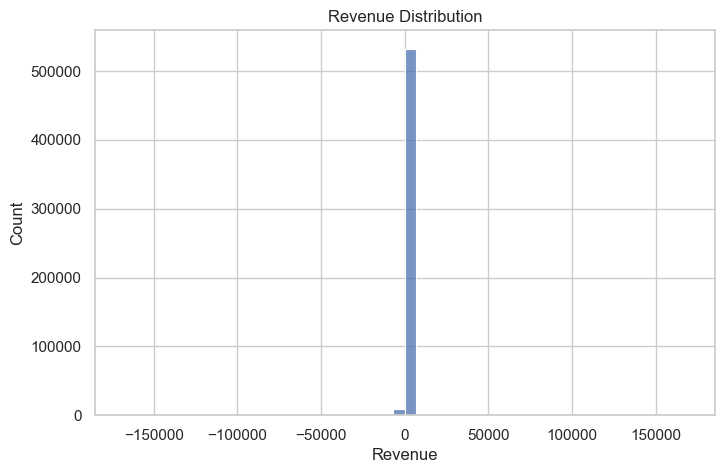

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df['Revenue'], bins=50)
plt.title("Revenue Distribution")
plt.show()

In [22]:
df[df['Quantity'] <= 0].shape

(10624, 9)

In [25]:
df[df['UnitPrice'] <= 0].shape

(2517, 9)

In [26]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month

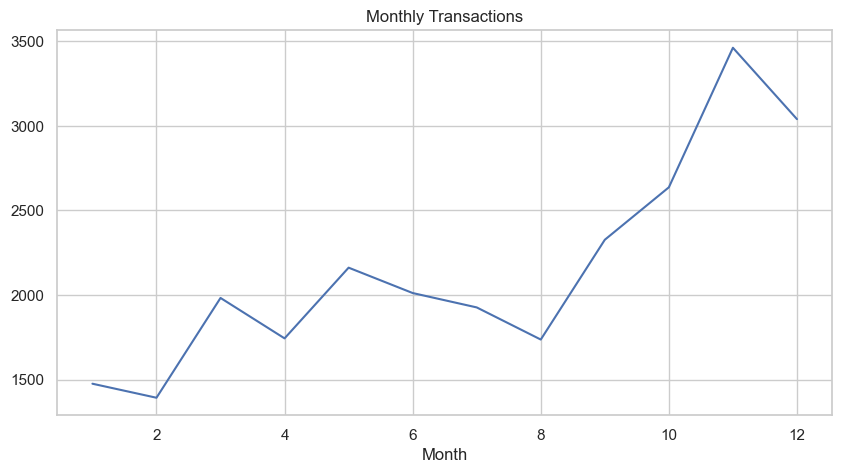

In [28]:
monthly = df.groupby('Month')['InvoiceNo'].nunique()

plt.figure(figsize=(10,5))
monthly.plot()
plt.title("Monthly Transactions")
plt.show()

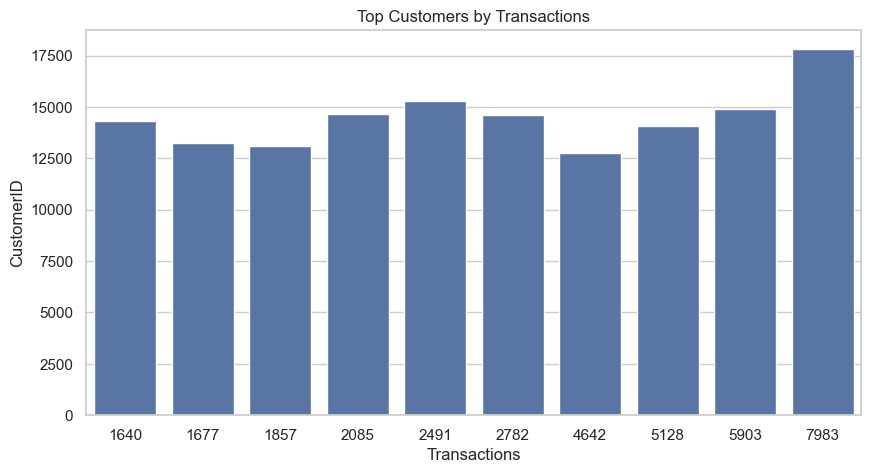

In [30]:
top_customers = df['CustomerID'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_customers.values, y=top_customers.index)
plt.title("Top Customers by Transactions")
plt.xlabel("Transactions")
plt.ylabel("CustomerID")
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['Quantity', 'UnitPrice', 'Revenue']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


KeyError: "['Price'] not in index"

<Figure size 800x500 with 0 Axes>